In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from utils import normalize

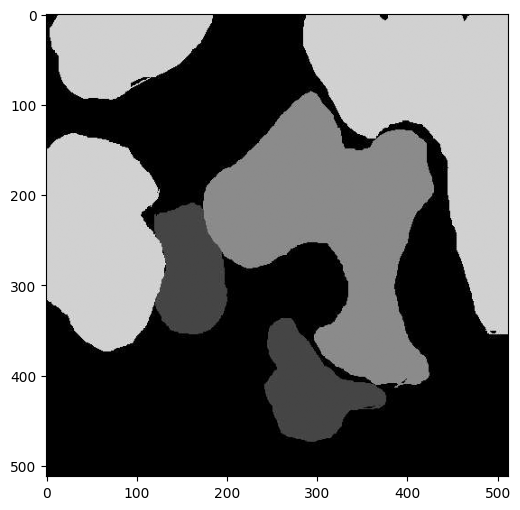

In [7]:
# Load a mask image
mask_path = '/home/nadun/wd/datasets/SICAP-test/masks/16B0001851/16B0001851_Block_Region_1_6_7_xini_13971_yini_65930.jpg'
mask = Image.open(mask_path)
mask_array = np.array(mask)

# Plot mask in greyscale
figure = plt.figure(figsize=(6, 6), dpi=100)
plt.imshow(mask_array, cmap='gray')
plt.show()

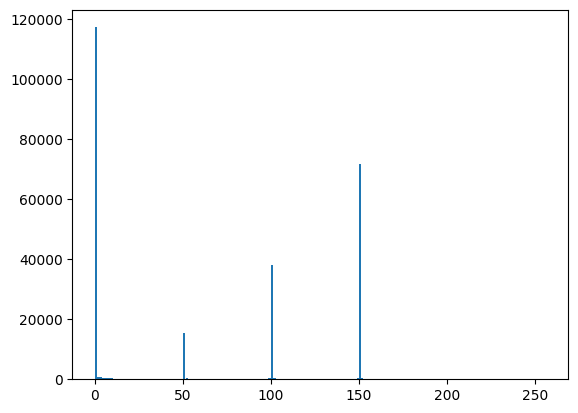

In [21]:
# Plot histogram of mask
plt.hist(mask_array.flatten(), bins=256, range=(0, 256))
plt.show()


In [8]:
mask_array.shape

(512, 512)

In [22]:
def remap(mask):
    mask_remapped = np.zeros_like(mask, dtype=np.int64)
    
    # Define intensity ranges
    mask_remapped[mask < 25] = 0      # Black
    mask_remapped[(mask >= 25) & (mask < 75)] = 1   # Dark gray
    mask_remapped[(mask >= 75) & (mask < 125)] = 2  # Light gray
    mask_remapped[mask >= 125] = 3    # White
    
    return mask_remapped

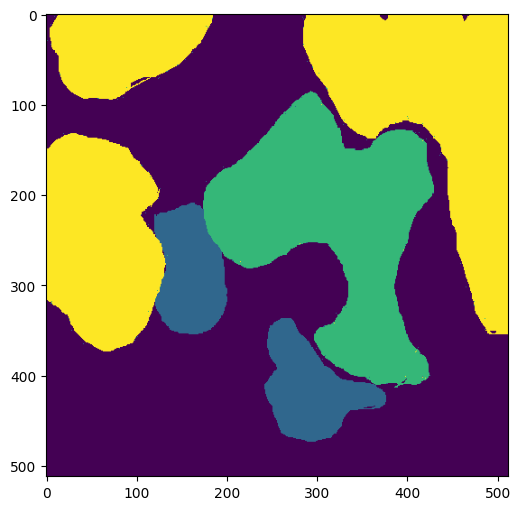

In [24]:
# Remap mask values to [0, 1, 2, 3]
mask_array_new = remap(mask_array)

# Plot mask in greyscale
figure = plt.figure(figsize=(6, 6), dpi=100)
plt.imshow(mask_array_new)
plt.show()